In [1]:
from myutils import imshow, plot
from time import time
from src import *

import torch

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

A = 5*DMD.PIXEL_SIZE / 2

sig = torch.tensor(DI.SIGMA, dtype=torch.float64).to(device)

iter = 10
samples_per_iter = 200

sample_length = 50
photons = 400

In [5]:
def main(f):
    loc = A * np.sign(np.sin(f * 2 * np.pi * np.arange(sample_length)))
    loc[loc == 0] = A
    loc = torch.from_numpy(loc).to(device)

    result = []

    for i in range(iter):
        random_mat = torch.randn(samples_per_iter, sample_length, photons, device=device)
        result_mat = random_mat * sig + loc[None, :, None]
        mean_mat = result_mat.mean(-1)
        result.append(mean_mat.cpu().numpy())

    data = np.vstack(result)

    freq_est = np.array([freq_estimator(data[i]) for i in range(data.shape[0])])
    return photons * freq_est.var()

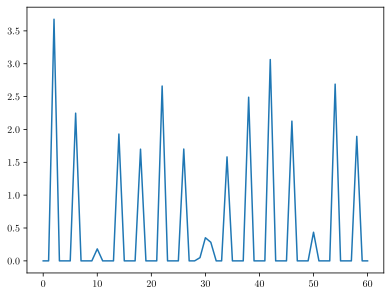

In [6]:
plot([main(f) for f in np.linspace(0.1, 0.4, 61)])